# Lab6.4-Topic-classification-BERT

Copyright: Vrije Universiteit Amsterdam, Faculty of Humanities, CLTL

In this notebook, we demonstrate how to fine-tune BERT for topic classification.

We will use the [simpletransformers library](https://simpletransformers.ai/):
 wrapper for the [huggingface transformers library](https://huggingface.co/) on PyTorch.

We are going to run the notebook on [colab](https://colab.research.google.com/?utm_source=scs-index), which has (limited) free access to GPUs.

You need to enable GPUs for the notebook:

* navigate to Edit → Notebook Settings
* select GPU from the Hardware Accelerator drop-down



### Install/import libraries

Install the simpletransformers library (restart your runtime after the installation)

In [3]:
# 1. Force the active notebook kernel to uninstall the bad versions
%pip uninstall -y transformers simpletransformers

# 2. Force the active notebook kernel to install the Golden Version
%pip install --no-cache-dir simpletransformers "transformers==4.29.2"

# 3. Prove to us exactly what version the notebook is holding in memory
import transformers
print("SUCCESS! The notebook is now actually using Transformers version:", transformers.__version__)

Error processing line 1 of /opt/anaconda3/envs/lab6-text-mining/lib/python3.10/site-packages/distutils-precedence.pth:

  Traceback (most recent call last):
    File "/opt/anaconda3/envs/lab6-text-mining/lib/python3.10/site.py", line 195, in addpackage
      exec(line)
    File "<string>", line 1, in <module>
  ModuleNotFoundError: No module named '_distutils_hack'

Remainder of file ignored
Found existing installation: transformers 4.29.2
Uninstalling transformers-4.29.2:
  Successfully uninstalled transformers-4.29.2
Found existing installation: simpletransformers 0.70.5
Uninstalling simpletransformers-0.70.5:
  Successfully uninstalled simpletransformers-0.70.5
Note: you may need to restart the kernel to use updated packages.
Error processing line 1 of /opt/anaconda3/envs/lab6-text-mining/lib/python3.10/site-packages/distutils-precedence.pth:

  Traceback (most recent call last):
    File "/opt/anaconda3/envs/lab6-text-mining/lib/python3.10/site.py", line 195, in addpackage
      ex

In [ ]:
# Pin the build tool to an older version to prevent the seqeval crash
!pip install "setuptools_scm<8.0"
!pip install simpletransformers

In [ ]:
# 1. Uninstall both again
!pip uninstall -y transformers simpletransformers

# 2. Obliterate the cached, broken transformers folder
!rm -rf /opt/anaconda3/envs/ba-text-mining/lib/python3.12/site-packages/transformers

# 3. Install the true magic version
!pip install simpletransformers "transformers==4.34.1"

In [4]:
# Import libraries
import pandas as pd
import numpy as np
import sklearn
from sklearn.metrics import classification_report
from simpletransformers.classification import ClassificationModel, ClassificationArgs
import matplotlib.pyplot as plt 
import seaborn as sn 

Import [the 20 newsgroups text dataset](https://scikit-learn.org/0.19/datasets/twenty_newsgroups.html).

The dataset contains around 18,000 newsgroups posts on 20 topics.

In [6]:
from sklearn.datasets import fetch_20newsgroups

# load only a sub-selection of the categories (4 in our case)
categories = ['alt.atheism', 'comp.graphics', 'sci.med', 'sci.space'] 

# remove the headers, footers and quotes (to avoid overfitting)
newsgroups_train = fetch_20newsgroups(subset='train', remove=('headers', 'footers', 'quotes'), categories=categories, random_state=42)
newsgroups_test = fetch_20newsgroups(subset='test', remove=('headers', 'footers', 'quotes'), categories=categories, random_state=42)

### Data exploration

The target attribute is the integer index of the category:

In [7]:
from collections import Counter
Counter(newsgroups_train.target)

Counter({np.int64(2): 594,
         np.int64(3): 593,
         np.int64(1): 584,
         np.int64(0): 480})

In [8]:
Counter(newsgroups_test.target)

Counter({np.int64(2): 396,
         np.int64(3): 394,
         np.int64(1): 389,
         np.int64(0): 319})

Convert data to pandas dataframe

In [9]:
train = pd.DataFrame({'text': newsgroups_train.data, 'labels': newsgroups_train.target})

In [10]:
print(len(train))
train.head(5)

2251


,text,labels
0,WHile we are on the subject of the shuttle sof...,3
1,There is a program called Graphic Workshop you...,1
2,,2
3,My girlfriend is in pain from kidney stones. S...,2
4,I think that's the correct spelling..\n\tI am ...,2


In [11]:
test = pd.DataFrame({'text': newsgroups_test.data, 'labels': newsgroups_test.target})

In [12]:
print(len(test))
test.head(5)

1498


,text,labels
0,\nAnd guess who's here in your place.\n\nPleas...,1
1,Does anyone know if any of Currier and Ives et...,1
2,=FLAME ON\n=\n=Reading through the posts about...,2
3,\nBut in this case I said I hoped that BCCI wa...,0
4,\nIn the kind I have made I used a Lite sour c...,2


Use a subset (10%) of the training set as a development set

In [13]:
from sklearn.model_selection import train_test_split

test = pd.DataFrame({'text': newsgroups_test.data, 'labels': newsgroups_test.target})
train, dev = train_test_split(train, test_size=0.1, random_state=0,
                               stratify=train[['labels']])

In [14]:
print(len(train))
print("train:", train[['labels']].value_counts(sort=False))
train.head(3)

2025
train: labels
0         432
1         525
2         534
3         534
Name: count, dtype: int64


,text,labels
559,I wonder how many atheists out there care to s...,0
2060,We are interested in purchasing a grayscale pr...,1
1206,"Dear Binary Newsers,\n\nI am looking for Quick...",1


In [15]:
print(len(dev))
print("dev:", dev[['labels']].value_counts(sort=False))
dev.head(3)

226
dev: labels
0         48
1         59
2         60
3         59
Name: count, dtype: int64


,text,labels
1570,I'd dump him. Rude is rude and it seems he en...,2
1761,Hi Everyone ::\n\nI am looking for some soft...,1
455,A friend of mine has been diagnosed with Psori...,2


## BERT

Define model's configuration

In [16]:
# Model configuration # https://simpletransformers.ai/docs/usage/#configuring-a-simple-transformers-model
model_args = ClassificationArgs()

model_args.overwrite_output_dir=True # overwrite existing saved models in the same directory
model_args.evaluate_during_training=True # to perform evaluation while training the model
# (eval data should be passed to the training method)

model_args.num_train_epochs=10 # number of epochs
model_args.train_batch_size=32 # batch size
model_args.learning_rate=4e-6 # learning rate
model_args.max_seq_length=256 # maximum sequence length
# Note! Increasing max_seq_len may provide better performance, but training time will increase.
# For educational purposes, we set max_seq_len to 256.

# Early stopping to combat overfitting: https://simpletransformers.ai/docs/tips-and-tricks/#using-early-stopping
model_args.use_early_stopping=True
model_args.early_stopping_delta=0.01 # "The improvement over best_eval_loss necessary to count as a better checkpoint"
model_args.early_stopping_metric='eval_loss'
model_args.early_stopping_metric_minimize=True
model_args.early_stopping_patience=2
model_args.evaluate_during_training_steps=32 # how often you want to run validation in terms of training steps (or batches)

With this configuration, the training will terminate if the eval_loss on the evaluation data does not improve upon the best eval_loss by at least 0.01 for 2 consecutive evaluations. 

An evaluation will occur once for every 32 training steps.

In [17]:
# Checking steps per epoch
steps_per_epoch = int(np.ceil(len(train) / float(model_args.train_batch_size)))
print('Each epoch will have {:,} steps.'.format(steps_per_epoch)) # 64 steps = validating 2 times per epoch

Each epoch will have 64 steps.


Load the pre-trained model: model_type = bert; model_name = [bert-base-cased](https://huggingface.co/bert-base-cased) (specifies the exact architecture and trained weights to use)

In [21]:
import torch
from simpletransformers.classification import ClassificationModel

# 1. Set up the model (Must use use_cuda=False so simpletransformers doesn't crash)
model = ClassificationModel(
    'bert',
    'bert-base-cased',
    num_labels=4,          #
    args=model_args,       #
    use_cuda=False
)

# 2. Manually force the PyTorch model onto Apple Silicon (MPS)
if torch.backends.mps.is_available():
    model.model.to(torch.device("mps"))
    print("Successfully pushed BERT to M3 Max GPU (MPS)!")
else:
    print("MPS not available, running on CPU.")

Some weights of the model checkpoint at bert-base-cased were not used when initializing BertForSequenceClassification: ['cls.predictions.transform.dense.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.bias', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.dense.weight']
- This IS expected if you are initializing BertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initi

Successfully pushed BERT to M3 Max GPU (MPS)!


In [22]:
print(str(model.args).replace(',', '\n')) # model args

ClassificationArgs(adafactor_beta1=None
 adafactor_clip_threshold=1.0
 adafactor_decay_rate=-0.8
 adafactor_eps=(1e-30
 0.001)
 adafactor_relative_step=True
 adafactor_scale_parameter=True
 adafactor_warmup_init=True
 adam_betas=(0.9
 0.999)
 adam_epsilon=1e-08
 best_model_dir='outputs/best_model'
 cache_dir='cache_dir/'
 config={}
 cosine_schedule_num_cycles=0.5
 custom_layer_parameters=[]
 custom_parameter_groups=[]
 dataloader_num_workers=0
 dataset_cache_dir=None
 do_lower_case=False
 dynamic_quantize=False
 early_stopping_consider_epochs=False
 early_stopping_delta=0.01
 early_stopping_metric='eval_loss'
 early_stopping_metric_minimize=True
 early_stopping_patience=2
 encoding=None
 eval_batch_size=100
 evaluate_during_training=True
 evaluate_during_training_silent=True
 evaluate_during_training_steps=32
 evaluate_during_training_verbose=False
 evaluate_each_epoch=True
 fp16=False
 gradient_accumulation_steps=1
 learning_rate=4e-06
 local_rank=-1
 logging_steps=50
 loss_type=None


Fine-tuning the model (takes a while)

In [23]:
_, history = model.train_model(train, eval_df=dev) 

Error processing line 1 of /opt/anaconda3/envs/lab6-text-mining/lib/python3.10/site-packages/distutils-precedence.pth:

  Traceback (most recent call last):
    File "/opt/anaconda3/envs/lab6-text-mining/lib/python3.10/site.py", line 195, in addpackage
      exec(line)
    File "<string>", line 1, in <module>
  ModuleNotFoundError: No module named '_distutils_hack'

Remainder of file ignored
Error processing line 1 of /opt/anaconda3/envs/lab6-text-mining/lib/python3.10/site-packages/distutils-precedence.pth:

  Traceback (most recent call last):
    File "/opt/anaconda3/envs/lab6-text-mining/lib/python3.10/site.py", line 195, in addpackage
      exec(line)
    File "<string>", line 1, in <module>
  ModuleNotFoundError: No module named '_distutils_hack'

Remainder of file ignored
Error processing line 1 of /opt/anaconda3/envs/lab6-text-mining/lib/python3.10/site-packages/distutils-precedence.pth:

  Traceback (most recent call last):
    File "/opt/anaconda3/envs/lab6-text-mining/lib/py

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

5it [00:03,  1.37it/s]                       
Epochs 0/10. Running Loss:    1.4043:  48%|████▊     | 31/64 [02:50<02:56,  5.34s/it]Error processing line 1 of /opt/anaconda3/envs/lab6-text-mining/lib/python3.10/site-packages/distutils-precedence.pth:

  Traceback (most recent call last):
    File "/opt/anaconda3/envs/lab6-text-mining/lib/python3.10/site.py", line 195, in addpackage
      exec(line)
    File "<string>", line 1, in <module>
  ModuleNotFoundError: No module named '_distutils_hack'

Remainder of file ignored
Error processing line 1 of /opt/anaconda3/envs/lab6-text-mining/lib/python3.10/site-packages/distutils-precedence.pth:

  Traceback (most recent call last):
    File "/opt/anaconda3/envs/lab6-text-mining/lib/python3.10/site.py", line 195, in addpackage
      exec(line)
    File "<string>", line 1, in <module>
  ModuleNotFoundError: No module named '_distutils_hack'

Remainder of file ignored
Error processing line 1 of /opt/anaconda3/envs/lab6-text-mining/lib/python3.10/

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)




Epochs 0/10. Running Loss:    1.2890:  98%|█████████▊| 63/64 [05:51<00:05,  5.29s/it]Error processing line 1 of /opt/anaconda3/envs/lab6-text-mining/lib/python3.10/site-packages/distutils-precedence.pth:

  Traceback (most recent call last):
    File "/opt/anaconda3/envs/lab6-text-mining/lib/python3.10/site.py", line 195, in addpackage
      exec(line)
    File "<string>", line 1, in <module>
  ModuleNotFoundError: No module named '_distutils_hack'

Remainder of file ignored
Error processing line 1 of /opt/anaconda3/envs/lab6-text-mining/lib/python3.10/site-packages/distutils-precedence.pth:

  Traceback (most recent call last):
    File "/opt/anaconda3/envs/lab6-text-mining/lib/python3.10/site.py", line 195, in addpackage
      exec(line)
    File "<string>", line 1, in <module>
  ModuleNotFoundError: No module named '_distutils_hack'

Remainder of file ignored
Error processing line 1 of /opt/anaconda3/envs/lab6-text-mining/lib/python3.10/site-packages/distutils-precedence.pth:

  T

...



Epochs 8/10. Running Loss:    0.1158: 100%|██████████| 64/64 [06:02<00:00,  5.67s/it]
Error processing line 1 of /opt/anaconda3/envs/lab6-text-mining/lib/python3.10/site-packages/distutils-precedence.pth:

  Traceback (most recent call last):
    File "/opt/anaconda3/envs/lab6-text-mining/lib/python3.10/site.py", line 195, in addpackage
      exec(line)
    File "<string>", line 1, in <module>
  ModuleNotFoundError: No module named '_distutils_hack'

Remainder of file ignored
Error processing line 1 of /opt/anaconda3/envs/lab6-text-mining/lib/python3.10/site-packages/distutils-precedence.pth:

  Traceback (most recent call last):
    File "/opt/anaconda3/envs/lab6-text-mining/lib/python3.10/site.py", line 195, in addpackage
      exec(line)
    File "<string>", line 1, in <module>
  ModuleNotFoundError: No module named '_distutils_hack'

Remainder of file ignored
Error processing line 1 of /opt/anaconda3/envs/lab6-text-mining/lib/python3.10/site-packages/distutils-precedence.pth:

  

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



Epochs 9/10. Running Loss:    0.1863:  48%|████▊     | 31/64 [02:48<02:54,  5.28s/it]Error processing line 1 of /opt/anaconda3/envs/lab6-text-mining/lib/python3.10/site-packages/distutils-precedence.pth:

  Traceback (most recent call last):
    File "/opt/anaconda3/envs/lab6-text-mining/lib/python3.10/site.py", line 195, in addpackage
      exec(line)
    File "<string>", line 1, in <module>
  ModuleNotFoundError: No module named '_distutils_hack'

Remainder of file ignored
Error processing line 1 of /opt/anaconda3/envs/lab6-text-mining/lib/python3.10/site-packages/distutils-precedence.pth:

  Traceback (most recent call last):
    File "/opt/anaconda3/envs/lab6-text-mining/lib/python3.10/site.py", line 195, in addpackage
      exec(line)
    File "<string>", line 1, in <module>
  ModuleNotFoundError: No module named '_distutils_hack'

Remainder of file ignored
Error processing line 1 of /opt/anaconda3/envs/lab6-text-mining/lib/python3.10/site-packages/distutils-precedence.pth:

  Tr

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



Epochs 9/10. Running Loss:    0.1863:  48%|████▊     | 31/64 [03:03<03:15,  5.93s/it]


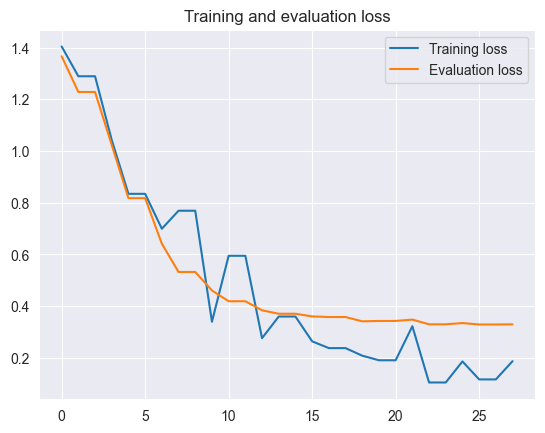

In [24]:
# Training and evaluation loss
train_loss = history['train_loss']
eval_loss = history['eval_loss']
plt.plot(train_loss, label='Training loss')
plt.plot(eval_loss, label='Evaluation loss')
plt.title('Training and evaluation loss')
plt.legend()

* Loss measures the “goodness” of your model

* The smaller the loss, the better the classifier is at modeling the relationship between the input data and the output targets

* But you need to be careful not to overfit

In our case, we stopped training because eval_loss loss did not improve upon the best eval_loss by at least 0.01 for 2 consecutive evaluations.

We can observe fluctuations in the training loss, but overall it is decreasing.
We can have a smoother learning curve by varying hyperparameters, e.g., learning rate, batch size.

In [25]:
# Evaluate the model
result, model_outputs, wrong_predictions = model.eval_model(dev)
result

Error processing line 1 of /opt/anaconda3/envs/lab6-text-mining/lib/python3.10/site-packages/distutils-precedence.pth:

  Traceback (most recent call last):
    File "/opt/anaconda3/envs/lab6-text-mining/lib/python3.10/site.py", line 195, in addpackage
      exec(line)
    File "<string>", line 1, in <module>
  ModuleNotFoundError: No module named '_distutils_hack'

Remainder of file ignored
Error processing line 1 of /opt/anaconda3/envs/lab6-text-mining/lib/python3.10/site-packages/distutils-precedence.pth:

  Traceback (most recent call last):
    File "/opt/anaconda3/envs/lab6-text-mining/lib/python3.10/site.py", line 195, in addpackage
      exec(line)
    File "<string>", line 1, in <module>
  ModuleNotFoundError: No module named '_distutils_hack'

Remainder of file ignored
Error processing line 1 of /opt/anaconda3/envs/lab6-text-mining/lib/python3.10/site-packages/distutils-precedence.pth:

  Traceback (most recent call last):
    File "/opt/anaconda3/envs/lab6-text-mining/lib/py

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Running Evaluation: 100%|██████████| 3/3 [00:08<00:00,  2.85s/it]


{'mcc': 0.8708292306355523, 'eval_loss': 0.3289043804009755}

* mcc: [ Matthews correlation coefficient](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.matthews_corrcoef.html)

* eval_loss: Cross Entropy Loss for dev

Make predictions with the model (predict the labels of the documents in the test set)

In [26]:
predicted, probabilities = model.predict(test.text.to_list())
test['predicted'] = predicted

Error processing line 1 of /opt/anaconda3/envs/lab6-text-mining/lib/python3.10/site-packages/distutils-precedence.pth:

  Traceback (most recent call last):
    File "/opt/anaconda3/envs/lab6-text-mining/lib/python3.10/site.py", line 195, in addpackage
      exec(line)
    File "<string>", line 1, in <module>
  ModuleNotFoundError: No module named '_distutils_hack'

Remainder of file ignored
Error processing line 1 of /opt/anaconda3/envs/lab6-text-mining/lib/python3.10/site-packages/distutils-precedence.pth:

  Traceback (most recent call last):
    File "/opt/anaconda3/envs/lab6-text-mining/lib/python3.10/site.py", line 195, in addpackage
      exec(line)
    File "<string>", line 1, in <module>
  ModuleNotFoundError: No module named '_distutils_hack'

Remainder of file ignored
Error processing line 1 of /opt/anaconda3/envs/lab6-text-mining/lib/python3.10/site-packages/distutils-precedence.pth:

  Traceback (most recent call last):
    File "/opt/anaconda3/envs/lab6-text-mining/lib/py

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


3it [00:02,  1.14it/s]                       
100%|██████████| 15/15 [01:07<00:00,  4.53s/it]


Test set predictions

In [27]:
test.head(5)

,text,labels,predicted
0,\nAnd guess who's here in your place.\n\nPleas...,1,1
1,Does anyone know if any of Currier and Ives et...,1,1
2,=FLAME ON\n=\n=Reading through the posts about...,2,0
3,\nBut in this case I said I hoped that BCCI wa...,0,0
4,\nIn the kind I have made I used a Lite sour c...,2,2


Evaluate the model's performance on the test set

In [28]:
# Result (note: your result can be different due to randomness in operations)
print(classification_report(test['labels'], test['predicted']))

              precision    recall  f1-score   support

           0       0.82      0.82      0.82       319
           1       0.90      0.91      0.90       389
           2       0.87      0.91      0.89       396
           3       0.88      0.82      0.85       394

    accuracy                           0.87      1498
   macro avg       0.87      0.87      0.86      1498
weighted avg       0.87      0.87      0.87      1498



### End of this notebook.